# Introdução

Este notebook (06_analise_semantica.ipynb) faz **descoberta de temas/intenções** a partir de mensagens já limpas, para apoiar curadoria e evolução da taxonomia do assistente.

**Objetivo principal**
- Agrupar mensagens por **similaridade semântica** e gerar insumos práticos (CSV/JSON) para rotulagem, definição/merge de intenções e priorização de melhorias.

**Fontes & estrutura**
- Lê `code/notebooks/dataset/dataset_unificado.csv` e usa a coluna **`mensagem_clean`** (renomeada para `texto`).
- Organização de caminhos e saídas em `code/notebooks/outputs/runs` (artefatos) e `.../models` (se necessário).
- Impressões auxiliares (`hr`, `pp`) para tornar o run auditável.

**Pipeline (visão geral)**
1. **Carregamento & limpeza:** deduplica `texto` e monta `dfq`.
2. **Embeddings:** gera vetores com `sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2` (multilíngue e robusto).
3. **Clusterização (não supervisionada):**
   - Tenta **HDBSCAN** (`min_cluster_size=30`, `metric="euclidean"`) — bom para densidades diferentes e ruído.
   - *Fallback:* **KMeans** com `k=14` e `random_state=42` para resultados estáveis quando HDBSCAN não estiver disponível.
4. **Diagnóstico rápido:**
   - Distribuição de clusters e **amostras por cluster** (até 6 exemplos).
   - **TF-IDF por cluster** para extrair termos mais característicos e facilitar batizar/colapsar intenções.
5. **Persistência & relatórios:**
   - `runs/clusters_questions.csv` (texto + cluster).
   - `runs/clusters_summary.json` (algoritmo, n_clusters, distribuição).
   - `runs/clusters_top6_samples.csv` (amostras resumidas).
   - `runs/clusters_exports.json` (ponteiros para tudo).
6. **Visualizações:** histograma da distribuição e **projeção 2D (PCA)** colorida por cluster.
7. **Integração com intenções existentes:**
   - Opcionalmente lê `notebook02_outputs/taxonomia_intencoes.json` para checar aderência/overlaps.
   - Imprime **sugestões preliminares** de novas intenções (lista de termos por cluster) para curadoria humana.
8. **Estatísticas finais:** métricas descritivas do tamanho dos clusters para orientar cortes/merges.

**Quando usar os resultados**
- Para **criar/ajustar** o `label_map.yaml` (aliases/colapsos).
- Para selecionar **clusters prioritários** (maior volume/impacto) na próxima rodada de **active learning** e no fine-tuning dos modelos de NLU/LLM.

In [18]:
# ============================================
# CÉLULA 2 — Setup e caminhos principais
# --------------------------------------------
# Objetivo: padronizar caminhos do projeto, helpers rápidos de log
# e garantir pastas de saída. Mantém compatibilidade com a estrutura
# usada nos outros notebooks (code/notebooks/...).
# Notas:
# - resolve_repo_root tenta achar a raiz do repo subindo diretórios
#   até encontrar sinais (requirements/README/.git) e a pasta "code".
# - RUNS e MODELS são criadas se não existirem (idempotente).
# - INTENTS é apenas logado aqui; o NB não lê esses dados diretamente.
# ============================================

import os, sys, json, pathlib, subprocess
from datetime import datetime
import pandas as pd
import numpy as np

def hr(title=None, ch="="):
    """Imprime uma linha horizontal para separar blocos no output."""
    print("\n" + ch*100)
    if title: print(title, "\n" + ch*100)

def pp(x):
    """Pretty print de dicionários/listas em JSON (UTF-8)."""
    print(json.dumps(x, ensure_ascii=False, indent=2))

def resolve_repo_root(start: pathlib.Path) -> pathlib.Path:
    """
    Sobe diretórios a partir de `start` até encontrar:
      - requirements.txt OU README.md OU .git
      - E também a pasta 'code'
    Retorna o primeiro match; se não achar, devolve o `start`.
    """
    for p in [start, *start.parents]:
        if ((p / "requirements.txt").exists() or (p / "README.md").exists() or (p / ".git").exists()) and (p / "code").exists():
            return p
    return start

# Descobre raíz e principais pastas do projeto
CWD  = pathlib.Path.cwd()
ROOT = resolve_repo_root(CWD)

DATA    = ROOT / "data"
CAT     = DATA / "catalog"
PROF    = DATA / "profiles"
INTENTS = DATA / "intents"     # <-- incluímos aqui!
NB      = ROOT / "code" / "notebooks"
OUT     = NB / "outputs"
RUNS    = OUT / "runs"
MODELS  = OUT / "models"

# Cria pastas de trabalho (não falha se já existirem)
for p in [RUNS, MODELS]: 
    p.mkdir(parents=True, exist_ok=True)

# Logs de conferência
print("ROOT:", ROOT)
print("DATA:", DATA)
print("RUNS:", RUNS)
print("MODELS:", MODELS)
print("INTENTS:", INTENTS)

ROOT: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04
DATA: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\data
RUNS: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\runs
MODELS: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\models
INTENTS: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\data\intents


In [19]:
# ============================================
# CÉLULA 3 — Carregar dataset unificado
# --------------------------------------------
# Espera um CSV consolidado em code/notebooks/dataset/dataset_unificado.csv
# com uma coluna 'mensagem_clean' (limpa) que será usada adiante.
# ============================================

ds_path = NB / "dataset" / "dataset_unificado.csv"
dfu = pd.read_csv(ds_path)

hr("Dataset unificado carregado")
print("Linhas:", len(dfu))
print("Colunas:", list(dfu.columns))
dfu.head(10)


Dataset unificado carregado 
Linhas: 1633
Colunas: ['texto', 'intent']


,texto,intent
0,consiggo falar com atendente?,falar_com_humano
1,"veioo com defeito, como faço a devolução?",troca_devolucao
2,que calca maravilhosa,duvida_tamanho
3,a jaqueta branca uma pena eu nao conseguir com...,duvida_tamanho
4,ela a c reta e certa acredito que o tamanho m ...,outros
5,conjuntinho,outros
6,somos uma produtora de a udio visual e achamos...,duvida_tamanho
7,essa modelagem é mais enxuta? o camisa de visc...,tamanho_modelagem
8,boa tarde fabiana como vai passando para avisa...,saudacao
9,tem calça alfaiataria verde 40?,buscar_produto_por_nome


In [20]:
# ============================================
# CÉLULA 4 — Seleção e limpeza de mensagens (ROBUSTA)
# --------------------------------------------
# - Detecta automaticamente a coluna de texto (mensagem_clean, texto, mensagem, message, content, utterance, body, text)
# - Renomeia para 'texto' (padrão dos outros NBs)
# - Remove nulos, trims e duplicatas
# - Loga qual coluna foi usada e quantas linhas ficaram
# ============================================

import pandas as pd

# 1) mapa lower->original para localizar colunas ignorando maiúsculas/minúsculas
cols_lc = {c.lower(): c for c in dfu.columns}

# 2) candidatos em ordem de preferência
candidatos = [
    "mensagem_clean", "texto", "mensagem",
    "message", "content", "utterance", "body", "text"
]

col_encontrada = None
for c in candidatos:
    if c in cols_lc:
        col_encontrada = cols_lc[c]
        break

if col_encontrada is None:
    raise KeyError(
        "Não encontrei coluna de texto. "
        f"Candidatos testados: {candidatos}. Colunas disponíveis: {list(dfu.columns)}"
    )

# 3) montagem do dfq padronizado
dfq = (
    dfu[[col_encontrada]]
      .rename(columns={col_encontrada: "texto"})
      .copy()
)

# 4) limpeza básica
# - converte para string, tira espaços das pontas
# - remove nulos e entradas vazias após strip
dfq["texto"] = dfq["texto"].astype(str).str.strip()
dfq = dfq.replace({"": pd.NA}).dropna(subset=["texto"])

# (opcional) filtrar textos muito curtos — comente/ajuste se não quiser
# dfq = dfq[dfq["texto"].str.len() >= 2]

# 5) deduplicação
antes = len(dfu)
dfq = dfq.drop_duplicates(subset=["texto"]).reset_index(drop=True)
depois = len(dfq)

# 6) logs
hr("Dataset para clustering (CÉLULA 4)")
print(f"Coluna usada: '{col_encontrada}' → renomeada para 'texto'")
print(f"Linhas originais: {antes} | Após limpeza+dedup: {depois}")
display(dfq.head(10))



Dataset para clustering (CÉLULA 4) 
Coluna usada: 'texto' → renomeada para 'texto'
Linhas originais: 1633 | Após limpeza+dedup: 1633


,texto
0,consiggo falar com atendente?
1,"veioo com defeito, como faço a devolução?"
2,que calca maravilhosa
3,a jaqueta branca uma pena eu nao conseguir com...
4,ela a c reta e certa acredito que o tamanho m ...
5,conjuntinho
6,somos uma produtora de a udio visual e achamos...
7,essa modelagem é mais enxuta? o camisa de visc...
8,boa tarde fabiana como vai passando para avisa...
9,tem calça alfaiataria verde 40?


In [21]:
# ============================================
# CÉLULA 5 — Geração de embeddings
# --------------------------------------------
# Modelo: paraphrase-multilingual-MiniLM-L12-v2 (rápido e robusto em PT-BR).
# - Retorna um array numpy (n_textos x dim)
# - show_progress_bar ajuda no acompanhamento.
# Dica: se os textos forem muito longos, considere truncá-los
#       ou usar um modelo maior (com custo de tempo/memória).
# ============================================

from sentence_transformers import SentenceTransformer

model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(model_name)

embeddings = embedder.encode(dfq["texto"].tolist(), convert_to_numpy=True, show_progress_bar=True)
print("Shape embeddings:", embeddings.shape)

Batches: 100%|██████████| 52/52 [00:02<00:00, 17.74it/s]

Shape embeddings: (1633, 384)


In [22]:
# ============================================
# CÉLULA 6 — Clusterização (ajustada)
# --------------------------------------------
# Preferência: HDBSCAN (métrica 'cosine', mais adequada a embeddings).
# Fallback: KMeans com mais n_init para estabilidade.
# Após clusterizar, já calcula e imprime a distribuição.
# ============================================

try:
    import hdbscan
    # dica: 'cosine' funciona muito bem para embeddings de sentenças
    clusterer = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=10, metric="cosine")
    labels = clusterer.fit_predict(embeddings)
    algoritmo = "hdbscan(cosine)"
except ImportError:
    from sklearn.cluster import KMeans
    k = 14  # heurística; ajuste conforme necessário
    clusterer = KMeans(n_clusters=k, random_state=42, n_init=25)
    labels = clusterer.fit_predict(embeddings)
    algoritmo = f"kmeans(k={k}, n_init=25, rs=42)"

dfq["cluster"] = labels
dist = dfq["cluster"].value_counts().sort_index()

hr("Clustering concluído")
print("Algoritmo:", algoritmo)
print("Clusters distintos:", len(set(labels)))
print("\nDistribuição (qtd por cluster):")
print(dist)



Clustering concluído 
Algoritmo: kmeans(k=14, n_init=25, rs=42)
Clusters distintos: 14

Distribuição (qtd por cluster):
cluster
0     113
1     153
2     160
3     129
4      71
5     207
6      63
7      91
8     255
9      36
10    188
11     62
12     61
13     44
Name: count, dtype: int64


# Notas de clusterização: HDBSCAN × KMeans e como ajustar

Este notebook tenta **HDBSCAN** primeiro (melhor para dados com densidades variadas) e cai para **KMeans** caso a lib não esteja instalada. Use este guia rápido para **ajustar**:

## Quando preferir HDBSCAN
- **Clusters de tamanhos/densidades diferentes** ou presença de ruído (etiqueta `-1`).
- Você quer **detectar “sem cluster”** automaticamente (itens ruidosos).
- Parametrizações úteis:
  - `min_cluster_size`: tamanho mínimo de um agrupamento “útil”.  
    • Aumente para **menos clusters, mais estáveis**; diminua para **mais clusters, mais granulares**.  
  - `min_samples`: robustez contra ruído (maior ⇒ mais conservador).
  - `metric`: se seu embedding veio de `SentenceTransformer`, `cosine` costuma funcionar bem.

> Ex.:  
> ```python
> import hdbscan
> clusterer = hdbscan.HDBSCAN(min_cluster_size=30, min_samples=10, metric="cosine")
> labels = clusterer.fit_predict(embeddings)
> ```

## Quando preferir KMeans
- Você precisa de **número de clusters fixo** para downstream.
- Dados mais “redondos” (distribuição semelhante por cluster).
- Dials principais:
  - `k`: número de clusters (no notebook está `k=14` como heurística).
  - `n_init`: 10–50 melhora estabilidade (mais inicializações).

> Ex.:  
> ```python
> from sklearn.cluster import KMeans
> k = 18  # tente 10, 14, 18, 22...
> clusterer = KMeans(n_clusters=k, random_state=42, n_init=25)
> labels = clusterer.fit_predict(embeddings)
> ```

## Como validar rápido
- **Distribuição de tamanhos** (próxima célula) — procure caudas muito longas (clusters minúsculos demais).
- **Coesão semântica**: verifique amostras por cluster (mais abaixo).
- (Opcional) **Silhouette** (para KMeans):  
  quanto mais alto (0→1), melhor separação média.

## Dicas práticas
- **Reprodutibilidade**: fixe `random_state=42` (KMeans, PCA etc.).  
- **Ruído no HDBSCAN**: muitos `-1`? Reduza `min_samples` ou `min_cluster_size`.  
- **Granularidade**: se os clusters estão “misturando temas”, **aumente k** (KMeans) ou **reduza min_cluster_size** (HDBSCAN).  
- **Custo/tempo**: HDBSCAN pode ser mais pesado; em ambientes limitados, KMeans é um bom atalho.


In [23]:
# ============================================
# CÉLULA 7 — Distribuição de clusters
# --------------------------------------------
# Mostra quantas mensagens caíram em cada cluster (inclui -1 se HDBSCAN).
# Útil para detectar clusters muito pequenos/grandes.
# ============================================

dist = dfq["cluster"].value_counts().sort_index()
hr("Distribuição de clusters")
print(dist)


Distribuição de clusters 
cluster
0     113
1     153
2     160
3     129
4      71
5     207
6      63
7      91
8     255
9      36
10    188
11     62
12     61
13     44
Name: count, dtype: int64


In [24]:
# ============================================
# CÉLULA 8 — Amostra de mensagens por cluster
# --------------------------------------------
# Para revisão humana rápida: mostra até 6 mensagens de cada
# um dos 5 primeiros clusters (por índice).
# ============================================

for cid in dist.index[:5]:  # mostra 5 clusters
    hr(f"Cluster {cid} (amostra)")
    print(dfq[dfq["cluster"]==cid]["texto"].head(6).to_string(index=False))


Cluster 0 (amostra) 
  obrigada pela presenca stella
  obrigada pela presenca silvia
         obrigada pela presenca
    muito obrigada pela atencao
obrigada pela presena a a i a i
 enviado obrigada ata c segunda

Cluster 1 (amostra) 
essa modelagem é mais enxuta? o camisa de visco...
            tem tabela de medidas do vestido midi?
fiz uma compra de um casaco com vcs e nao vesti...
veste pequeno ou grande? queria o saia plissada...
                             quero camisa preto 46
                aindda tem calça alfaiataria em G?

Cluster 2 (amostra) 
                     consiggo falar com atendente?
         veioo com defeito, como faço a devolução?
a jaqueta branca uma pena eu nao conseguir comp...
                      não serviu, consigo troocar?
                  é algodão? encolhe? comoo lavar?
                     pagamentoo recusado toda hora

Cluster 3 (amostra) 
ela a c reta e certa acredito que o tamanho m f...
posso trocar caso eu experimente e prefira uma ...
pergun

In [25]:
# ============================================
# CÉLULA 9 — Salvar CSV com mensagens + cluster
# --------------------------------------------
# Salva em RUNS/clusters_questions.csv para consumo posterior
# (curadoria, rotulagem, análises).
# ============================================

clusters_csv = RUNS / "clusters_questions.csv"
dfq.to_csv(clusters_csv, index=False)
print("Clusters salvos em:", clusters_csv)

Clusters salvos em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\runs\clusters_questions.csv


In [26]:
# ============================================
# CÉLULA 10 — Salvar resumo em JSON
# --------------------------------------------
# Grava metadados do agrupamento: algoritmo usado, nº de clusters
# e distribuição (dict cluster->qtd). Facilita comparações entre runs.
# ============================================

clusters_summary = {
    "algoritmo": algoritmo,
    "n_clusters": int(len(set(labels))),
    "distribuicao": dist.to_dict()
}
clusters_json = RUNS / "clusters_summary.json"
clusters_json.write_text(json.dumps(clusters_summary, ensure_ascii=False, indent=2), encoding="utf-8")
print("Resumo salvo em:", clusters_json)
pp(clusters_summary)

Resumo salvo em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\runs\clusters_summary.json
{
  "algoritmo": "kmeans(k=14, n_init=25, rs=42)",
  "n_clusters": 14,
  "distribuicao": {
    "0": 113,
    "1": 153,
    "2": 160,
    "3": 129,
    "4": 71,
    "5": 207,
    "6": 63,
    "7": 91,
    "8": 255,
    "9": 36,
    "10": 188,
    "11": 62,
    "12": 61,
    "13": 44
  }
}


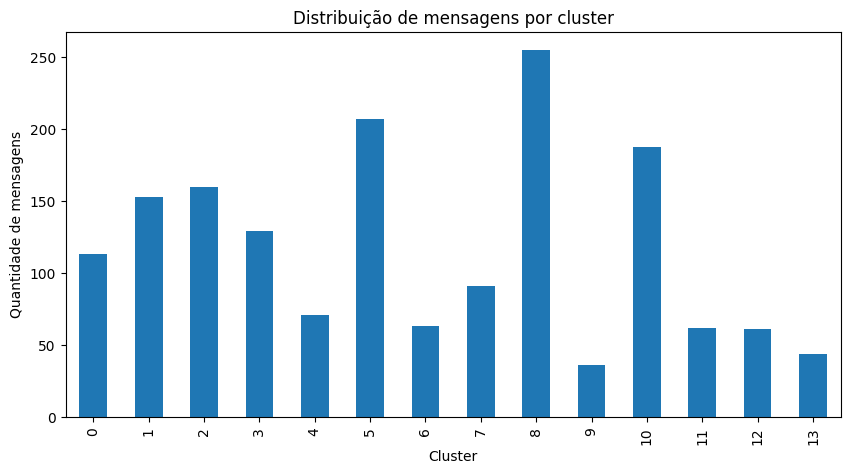

In [27]:
# ============================================
# CÉLULA 11 — Visualização: distribuição de clusters
# --------------------------------------------
# Gráfico de barras simples com a contagem de mensagens por cluster.
# Se houver muitos clusters, considere plotar apenas os top-N.
# ============================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
dist.plot(kind="bar")
plt.title("Distribuição de mensagens por cluster")
plt.xlabel("Cluster")
plt.ylabel("Quantidade de mensagens")
plt.show()

In [28]:
# ============================================
# CÉLULA 12 — Top termos por cluster
# --------------------------------------------
# - TF-IDF (1-gram padrão do TfidfVectorizer)
# - Pequena stoplist PT-BR para limpar palavras funcionais.
# - Retorna os N termos com maior TF-IDF médio no cluster.
# Observação: Para PT-BR, pode-se usar tokenização mais rica
# (spaCy/PTBR, n-gramas 1–2, normalização de acentos, etc.)
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer

stop_pt = {"a","o","as","os","de","do","da","das","dos","e","é","em","um","uma","para","pra","por","com","que","se","me","te","não","sim","tá","foi","era"}
dfq["_clean"] = dfq["texto"].fillna("").astype(str)

def top_terms_for_cluster(cid, n=12):
    """
    Calcula TF-IDF no subconjunto do cluster `cid` e retorna
    os `n` termos com maior média de TF-IDF.
    """
    sub = dfq[dfq["cluster"]==cid]
    vect = TfidfVectorizer(max_features=5000, stop_words=list(stop_pt))
    try:
        X = vect.fit_transform(sub["_clean"])
        mean_scores = X.mean(axis=0).A1
        idx = mean_scores.argsort()[::-1][:n]
        vocab_inv = {v:k for k,v in vect.vocabulary_.items()}
        return [(vocab_inv[i], float(mean_scores[i])) for i in idx]
    except ValueError:
        # pode ocorrer se o cluster tiver 0/1 documentos após limpeza
        return []

# Prévia de top termos para até 5 clusters
for cid in dist.index[:5]:
    hr(f"Cluster {cid} — top termos")
    print(top_terms_for_cluster(cid, n=12))



Cluster 0 — top termos 
[('obrigada', 0.16217911866785997), ('muito', 0.06443895835418731), ('pelo', 0.06308158662494386), ('pela', 0.057193381867397725), ('ok', 0.038344117644557495), ('retorno', 0.0383424909216878), ('perfeito', 0.037743093453191844), ('bom', 0.03704203516815911), ('dia', 0.03246512618634549), ('mto', 0.03164235429730844), ('presena', 0.031574137494406795), ('ana', 0.031208013766694985)]

Cluster 1 — top termos 
[('camisa', 0.0903557886976166), ('quero', 0.07774780338694909), ('preto', 0.05709290882794447), ('calça', 0.055215813615326854), ('jaqueta', 0.05426798519316769), ('viscose', 0.05405955239093229), ('tem', 0.04811177405438765), ('usar', 0.04437075935237702), ('vestido', 0.044045505201768), ('off', 0.04368108320868524), ('algo', 0.04329478862860713), ('posso', 0.04329478862860713)]

Cluster 2 — top termos 
[('consigo', 0.05256875727717093), ('como', 0.05104491018335888), ('posso', 0.04997269698617268), ('especial', 0.04104788664530666), ('no', 0.0409795593911

In [29]:
# ============================================
# CÉLULA 12B — Diagnóstico de clusters sem termos (TF-IDF vazio)
# --------------------------------------------
# Lista clusters cujo top_terms_for_cluster() retornou vazio,
# tipicamente por terem 0/1 documento útil após limpeza.
# Útil para decidir merges/splits na curadoria.
# ============================================

sem_termos = []
for cid in dist.index:
    termos = top_terms_for_cluster(cid, n=8)
    if not termos:
        sem_termos.append(int(cid))

hr("Clusters sem termos TF-IDF (provável muito pequenos/ruído)")
print(sem_termos if sem_termos else "Todos os clusters possuem termos extraídos.")



Clusters sem termos TF-IDF (provável muito pequenos/ruído) 
Todos os clusters possuem termos extraídos.


In [30]:
# ============================================
# CÉLULA 13 — Exportar amostras resumidas (top 6 por cluster)
# --------------------------------------------
# Útil para mandar para revisão rápida (planilha, anotações manuais).
# ============================================

top6_path = RUNS / "clusters_top6_samples.csv"
rows = []
for cid in dist.index:
    subset = dfq[dfq["cluster"]==cid].head(6)
    for txt in subset["texto"]:
        rows.append({"cluster": cid, "texto": txt})
pd.DataFrame(rows).to_csv(top6_path, index=False)
print("Top 6 amostras salvas em:", top6_path)

Top 6 amostras salvas em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\runs\clusters_top6_samples.csv


In [31]:
# ============================================
# CÉLULA 14 — Ligação com intenções existentes (robusta a caminho)
# --------------------------------------------
from pathlib import Path

candidatos = [
    NB / "outputs" / "notebook02_outputs" / "taxonomia_intencoes.json",
    ROOT / "code" / "notebooks" / "outputs" / "notebook02_outputs" / "taxonomia_intencoes.json",
    ROOT / "notebook02_outputs" / "taxonomia_intencoes.json",
]
tax_path = next((p for p in candidatos if Path(p).exists()), None)

if tax_path:
    intencoes_existentes = json.loads(Path(tax_path).read_text(encoding="utf-8"))
    hr("Intenções existentes")
    print(intencoes_existentes.keys())
else:
    print("⚠ Arquivo de taxonomia não encontrado em:", [str(p) for p in candidatos])



Intenções existentes 
dict_keys(['saudacao', 'agradecimento', 'despedida', 'duvida_tamanho', 'pedido_sugestao', 'disponibilidade', 'preco_pagamento', 'prazo_entrega', 'troca_devolucao', 'onde_comprar', 'cupom_primeira', 'erro_plataforma', 'outros'])


# Do cluster à ação: curadoria de intenções e próximos passos

Agora que temos **clusters** e **termos/top amostras**, o objetivo é **mapear cada cluster** para uma intenção existente ou propor uma nova. Use este checklist:

## 1) Diagnóstico por cluster
- Veja `RUNS/clusters_top6_samples.csv` e os **Top termos** (Cél. 12).  
- Pergunte-se: *as mensagens compartilham intenção prática (ex.: “frete/prazo”, “tamanho/modelagem”, “pagamento/checkout”)?*

## 2) Decisão de mapeamento
- **Casa com intenção existente** (ver `notebook02_outputs/taxonomia_intencoes.json`).  
  - Se só muda a forma de falar, trate como **alias** (mesma intenção).  
- **Nova intenção**: quando houver **objetivo recorrente não coberto**.  
  - Dê um nome claro, curto, “verbo + objeto” (ex.: `troca_devolucao`, `styling_sugestao_look`).

## 3) Documente o racional
- Para cada cluster, registre: **exemplos**, **termos**, **decisão** (existente/novo), e **motivo**.  
- Marque **ambiguidade** para quebra futura (ex.: “tamanho” × “troca por tamanho” → intenções diferentes).

## 4) Higiene de dados
- **Ruído/outliers**: se HDBSCAN gerou `-1`, avalie excluir ou reclassificar manualmente.  
- **Clusters minúsculos** (1–2 msgs) em KMeans podem ser **sobra de inicialização** — considere fundir com o vizinho mais próximo.

## 5) Atualizações downstream (fora deste notebook)
- **Rotulagem**: gere um CSV para rotular ou corrigir rótulos existentes por cluster.  
- **label_map/collapse**: crie aliases para sinônimos comuns (ex.: “frete”, “entrega”, “prazo”).  
- **Re-treino** do classificador de intenções com o conjunto revisado.

> Dica: priorize clusters com **alto volume** e **alto impacto** (ex.: problemas de checkout, status de pedido).  
> Use a distribuição (Cél. 7) para guiar sua fila de curadoria.


In [32]:
# ============================================
# CÉLULA 15 — Sugestões de novas intenções a partir de clusters
# --------------------------------------------
# Rascunho: imprime candidatos (top 5 termos) para cada um
# dos primeiros clusters. A curadoria humana é essencial
# para nomear e consolidar intents de forma consistente.
# ============================================

print("Sugestões preliminares (manual/curadoria necessária):")
for cid in dist.index[:5]:
    termos = [w for w,_ in top_terms_for_cluster(cid, n=5)]
    print(f"- Cluster {cid}: candidatos ->", termos)

Sugestões preliminares (manual/curadoria necessária):
- Cluster 0: candidatos -> ['obrigada', 'muito', 'pelo', 'pela', 'ok']
- Cluster 1: candidatos -> ['camisa', 'quero', 'preto', 'calça', 'jaqueta']
- Cluster 2: candidatos -> ['consigo', 'como', 'posso', 'especial', 'no']
- Cluster 3: candidatos -> ['tamanho', 'num', 'body', 'tem', 'quadril']
- Cluster 4: candidatos -> ['preto', 'tem', 'no', 'body', 'blazer']


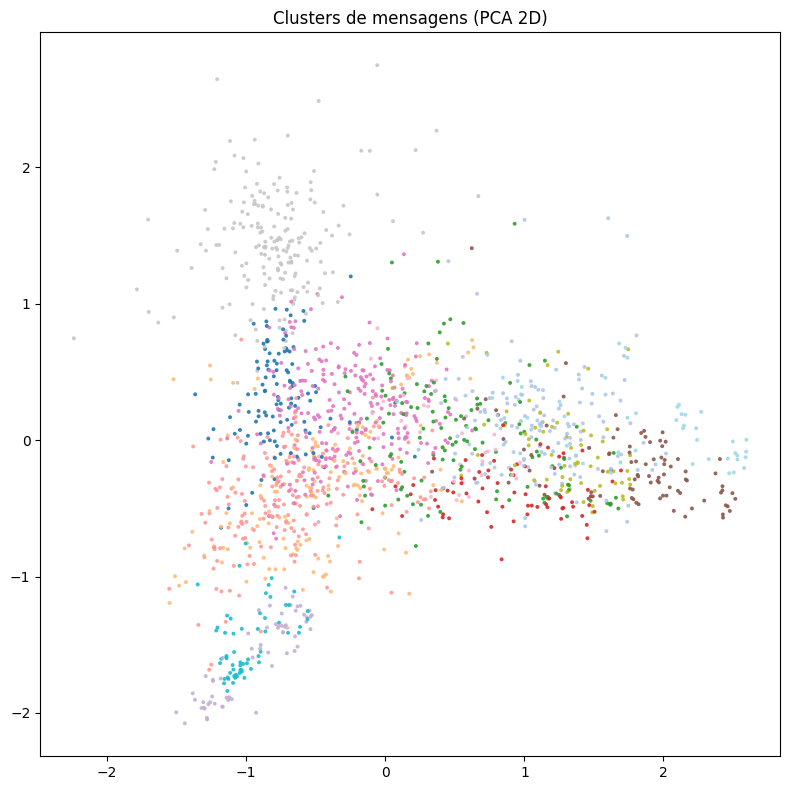

In [33]:
# ============================================
# CÉLULA 16 — Visualização 2D com PCA (determinística)
# --------------------------------------------
from sklearn.decomposition import PCA
import numpy as np
import matplotlib.pyplot as plt

# Seed para reprodutibilidade
rng = np.random.default_rng(42)

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

# Mapa de cores fixo baseado no índice do cluster
uniq = sorted(set(labels))
color_map = {cid: i for i, cid in enumerate(uniq)}
cvals = np.array([color_map[c] for c in labels], dtype=int)

plt.figure(figsize=(8,8))
plt.scatter(coords[:,0], coords[:,1], c=cvals, cmap="tab20", s=8, alpha=0.9, edgecolors="none")
plt.title("Clusters de mensagens (PCA 2D)")
plt.tight_layout()
plt.show()


In [34]:
# ============================================
# CÉLULA 17 — Estatísticas de tamanho dos clusters
# --------------------------------------------
# Descritivo simples da distribuição (count, mean, std, min, quartis, max).
# Bom para entender desequilíbrios de tamanho entre grupos.
# ============================================

sizes = dist.describe()
hr("Estatísticas dos clusters")
print(sizes)


Estatísticas dos clusters 
count     14.000000
mean     116.642857
std       67.509096
min       36.000000
25%       62.250000
50%      102.000000
75%      158.250000
max      255.000000
Name: count, dtype: float64


In [35]:
# ============================================
# CÉLULA 18 — Export final consolidado
# --------------------------------------------
# Centraliza referências dos arquivos gerados em um JSON único,
# facilitando integrações downstream ou reabertura de resultados.
# ============================================

export = {
    "clusters_csv": str(clusters_csv),
    "clusters_summary": str(clusters_json),
    "clusters_top6_samples": str(top6_path)
}
final_json = RUNS / "clusters_exports.json"
final_json.write_text(json.dumps(export, indent=2), encoding="utf-8")
print("Export final em:", final_json)

Export final em: c:\Users\win\Documents\GitHub\2025-2A-T07-CC11-G04\code\notebooks\outputs\runs\clusters_exports.json


# Conclusão

**O que foi produzido**
- Clusters de mensagens com:
  - **Distribuição** por cluster e **amostras** representativas.
  - **Top termos (TF-IDF)** por cluster — apoio direto à nomeação e colapso de intents.
- Artefatos persistidos e versionáveis:
  - `runs/clusters_questions.csv`
  - `runs/clusters_summary.json`
  - `runs/clusters_top6_samples.csv`
  - `runs/clusters_exports.json` (índice das saídas)

**Como interpretar**
- Clusters com muitos itens e termos coesos indicam **candidatos fortes a intenção** (ou subintenção).
- Clusters pequenos e heterogêneos podem sinalizar **ruído**, casos raros ou **lacunas** na limpeza/stopwords.
- Se o fallback de KMeans foi usado, os agrupamentos podem ficar **menos sensíveis a densidade**; vale reprocessar com HDBSCAN quando disponível.

**Próximos passos recomendados**
1. **Curadoria humana**: revisar `clusters_top6_samples.csv` e batizar clusters; decidir **merge/split**.
2. **Taxonomia/label_map**: transformar os nomes decididos em **aliases/colapsos** (ex.: `collapse_to`), alimentando o pipeline dos NBs 07–09.
3. **Refinar granularidade**:
   - HDBSCAN: ajustar `min_cluster_size` e (se necessário) métrica.
   - KMeans (fallback): testar `k` diferentes e comparar distribuição/coerência semântica.
4. **Stopwords de domínio**: enriquecer lista (marcas, termos ultrafrequentes) para termos TF-IDF mais informativos.
5. **Integração com intents existentes**: mapear clusters a intenções já definidas, detectar lacunas e **novas intenções**.
6. **Qualidade & robustez**: remover quase-duplicatas, tratar outliers e reexecutar para estabilizar clusters.

**Limitações & cuidados**
- É um passo **não supervisionado**: requer validação humana antes de virar rótulo em produção.
- Resultados dependem do **modelo de embeddings** e dos parâmetros de clusterização; documente versões/ seeds.
- Mudanças na limpeza (stopwords, normalização) podem alterar significativamente os agrupamentos — **registre o run** (os JSON/CSV produzidos já ajudam).

Com isso, você tem uma **base sólida e auditável** para transformar massa de mensagens em **intens/temas concretos**, acelerar rotulagem e orientar próximas iterações de NLU/LLM.